# Marine 48h Forecast — Hybrid v3: iTransformer + Quantile XGBoost (Cross-Features + Event Weighting)

Two hybrid attempts so far on the 6 historically hard parameters (precipitation ×2,
visibility ×4):

| Approach | Mean skill, hard 6 |
|---|---|
| Pure iTransformer | −208.1% |
| DeepAR-hybrid | +2.2% |
| XGBoost-hybrid v2 (Tweedie/Huber) | −1.3% |

Neither hybrid decisively beat the other — both converge near the persistence floor.
A literature comparison table for these exact parameter categories points to **three
concrete things neither v1 nor v2 actually tried**:

1. **Cross-parameter meteorological features.** The table lists `relativeHumidity`,
   `dewPointTemperature`, and `windSpeed` as key inputs for *both* precipitation and
   visibility — fog physically forms when the dew point approaches air temperature
   (RH→100%), and rain probability/intensity correlates with humidity and pressure. v1
   and v2 only ever fed each hard parameter **its own lagged history** + calendar —
   real, physically-relevant signal was being ignored.
2. **Quantile regression at the median (q=0.5)**, which directly optimizes MAE — the
   actual metric this whole project is scored on. Tweedie deviance and Gaussian NLL are
   both *proxies* for MAE, not equal to it. For a distribution that's 82-96.5% exact
   zeros (precipitation) or sitting almost always at a ceiling (visibility), the median
   is naturally well-behaved without any distribution-specific tuning: median of
   mostly-zeros is zero; median of mostly-ceiling is near-ceiling.
3. **Rare-event sample weighting** — up-weighting non-zero precipitation rows and
   low-visibility rows during training, matching the table's "LSTM with weighted loss"
   recommendation. This project already used exactly this trick for the precipitation
   *type* classifier (`sample_weight`, 15× on rare classes) but never carried it over to
   the regression targets.

This notebook keeps iTransformer unchanged for the 18 "good" parameters and rebuilds the
6 hard parameters' models with all three fixes combined. Fully standalone.

## 0. Setup

In [1]:
import time
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cpu")
torch.set_num_threads(8)

print("PyTorch:", torch.__version__, "| XGBoost:", xgb.__version__, "| torch threads:", torch.get_num_threads())


PyTorch: 2.12.1+cpu | XGBoost: 3.2.0 | torch threads: 8


## 1. Load data, collapse duplicates, encode circular parameters

In [2]:
df_10min = pd.read_csv("ems_10min_resampled.csv", index_col=0, parse_dates=True)
DUPLICATES = [
    ("airTemperature", "windChillTemperature"),
    ("tideLevel", "tidePressure"),
    ("tideLevel", "waterPressure"),
    ("tideLevel", "waterLevel"),
    ("waterTemperature", "waterTemperature_WQ"),
    ("significantWaveHeight", "maxWaveHeight"),
]
df_cat = df_10min[["precipitationType"]].copy()
df_num = df_10min.drop(columns=["precipitationType"]).copy()

CIRCULAR = ["windDirection", "currentDirection", "compass"]
for c in CIRCULAR:
    rad = np.deg2rad(df_num[c])
    df_num[f"{c}_sin"] = np.sin(rad)
    df_num[f"{c}_cos"] = np.cos(rad)
df_num_full = df_num.drop(columns=CIRCULAR)

target_cols = [c for c in df_num_full.columns if c not in [d for _, d in DUPLICATES]]
n_targets = len(target_cols)

PRECIP_PARAMS = ["precipitationIntensity", "precipitationDifference"]
VISIBILITY_PARAMS = ["twentyFourHourAvgVisibility", "tenMinuteAvgVisibility",
                      "oneMinuteAvgVisibility", "oneHourAvgVisibility"]
HARD_PARAMS = PRECIP_PARAMS + VISIBILITY_PARAMS
GOOD_PARAMS = [c for c in target_cols if c not in HARD_PARAMS]

# Literature-flagged cross-features for the hard 6, per the comparison table
CROSS_FEATURES = ["relativeHumidity", "dewPointTemperature", "windSpeed", "airPressure"]
print(f"iTransformer: {len(GOOD_PARAMS)} parameters | XGBoost (quantile+cross-features): {len(HARD_PARAMS)} parameters")
print(f"Cross-features fed to the hard 6: {CROSS_FEATURES}")


iTransformer: 21 parameters | XGBoost (quantile+cross-features): 6 parameters
Cross-features fed to the hard 6: ['relativeHumidity', 'dewPointTemperature', 'windSpeed', 'airPressure']


## 2. Train/test split, duplicate reconstruction fit, scaling

In [3]:
LOOKBACK, HORIZON = 288, 288   # 2 days lookback, 48h horizon @ 10-min steps

idx = df_num_full.index
df_num_full["hour_sin"] = np.sin(2 * np.pi * idx.hour / 24)
df_num_full["hour_cos"] = np.cos(2 * np.pi * idx.hour / 24)
df_num_full["dom_sin"] = np.sin(2 * np.pi * idx.day / 30)
df_num_full["dom_cos"] = np.cos(2 * np.pi * idx.day / 30)
calendar_cols = ["hour_sin", "hour_cos", "dom_sin", "dom_cos"]

feature_cols = target_cols + calendar_cols
model_data = df_num_full[feature_cols].copy()
n_features = len(feature_cols)
target_idx = [feature_cols.index(c) for c in target_cols]
good_idx = [feature_cols.index(c) for c in GOOD_PARAMS]
calendar_idx = [feature_cols.index(c) for c in calendar_cols]

train_df = model_data.iloc[:-HORIZON].copy()
test_df = model_data.iloc[-HORIZON:].copy()
mean, std = train_df.mean(), train_df.std().replace(0, 1)
train_scaled = (train_df - mean) / std
full_scaled = (model_data - mean) / std

print(f"Train: {train_df.shape[0]} rows ({train_df.shape[0]/144:.1f} days)")
print(f"Test : {test_df.shape[0]} rows ({test_df.shape[0]/144:.1f} days)")


Train: 4032 rows (28.0 days)
Test : 288 rows (2.0 days)


In [4]:
recon_coef = {}
for keep, drop in DUPLICATES:
    x, y = train_df[keep].values, df_num_full[drop].iloc[:-HORIZON].values
    slope, intercept = np.polyfit(x, y, 1)
    pred_train = slope * x + intercept
    r2 = 1 - np.sum((y - pred_train) ** 2) / np.sum((y - y.mean()) ** 2)
    recon_coef[drop] = (keep, float(slope), float(intercept), float(r2))


## 3. Model A — iTransformer (18 "good" parameters, unchanged from v1/v2)

In [5]:
def make_direct_windows(scaled_df, lookback, horizon, out_idx):
    arr = scaled_df.values.astype(np.float32)
    X, Y = [], []
    for origin in range(lookback, len(arr) - horizon):
        X.append(arr[origin - lookback:origin])
        Y.append(arr[origin:origin + horizon][:, out_idx])
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

X_direct, Y_good = make_direct_windows(train_scaled, LOOKBACK, HORIZON, good_idx)
X_t, Y_good_t = torch.from_numpy(X_direct), torch.from_numpy(Y_good)
n_val = max(1, int(0.1 * len(X_t)))
X_tr, Y_tr_good = X_t[:-n_val], Y_good_t[:-n_val]
X_val, Y_val_good = X_t[-n_val:], Y_good_t[-n_val:]
last_window = torch.from_numpy(train_scaled.values[-LOOKBACK:].astype(np.float32)).unsqueeze(0)


class ITransformer(nn.Module):
    def __init__(self, lookback, n_features, horizon, out_idx, d_model=64, n_heads=4,
                 n_layers=2, dropout=0.1):
        super().__init__()
        self.out_idx = out_idx
        self.embed = nn.Linear(lookback, d_model)
        self.var_id = nn.Parameter(torch.randn(n_features, d_model) * 0.02)
        layer = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=d_model * 2,
                                            dropout=dropout, batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, n_layers)
        self.head = nn.Linear(d_model, horizon)

    def forward(self, x):
        tok = self.embed(x.transpose(1, 2)) + self.var_id.unsqueeze(0)
        tok = self.encoder(tok)
        out = self.head(tok)
        return out.transpose(1, 2)[:, :, self.out_idx]


def train_model(model, X_tr, Y_tr, X_val, Y_val, epochs=150, batch_size=64, lr=1e-3,
                 patience=20, name=""):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=6)
    loss_fn = nn.MSELoss()
    best_val, best_state, wait = float("inf"), None, 0
    n = len(X_tr); t0 = time.time()
    for ep in range(epochs):
        ep_t0 = time.time()
        model.train()
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            b = perm[i:i + batch_size]
            xb, yb = X_tr[b].to(device), Y_tr[b].to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val.to(device)), Y_val.to(device)).item()
        sched.step(val_loss)
        print(f"  [{name}] epoch {ep+1:3d}/{epochs}  val_loss={val_loss:.4f}  "
              f"epoch_time={time.time()-ep_t0:.1f}s  elapsed={time.time()-t0:.0f}s", flush=True)
        if val_loss < best_val - 1e-5:
            best_val, wait = val_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    model.eval()
    print(f"{name:14s} best_val_loss={best_val:.4f}  epochs_run={ep+1:3d}  time={time.time()-t0:5.1f}s")
    return model

itransformer = ITransformer(LOOKBACK, n_features, HORIZON, good_idx, d_model=64, n_heads=4, n_layers=2)
itransformer = train_model(itransformer, X_tr, Y_tr_good, X_val, Y_val_good, epochs=150, patience=20,
                            name="iTransformer")

with torch.no_grad():
    good_pred_scaled = itransformer(last_window.to(device))[0].cpu().numpy()
good_preds_real = good_pred_scaled * std[GOOD_PARAMS].values + mean[GOOD_PARAMS].values
good_pred_df = pd.DataFrame(good_preds_real, columns=GOOD_PARAMS, index=test_df.index)
print("iTransformer 48h forecast complete (18 parameters).")


  [iTransformer] epoch   1/150  val_loss=0.4280  epoch_time=1.0s  elapsed=1s


  [iTransformer] epoch   2/150  val_loss=0.3269  epoch_time=0.9s  elapsed=2s


  [iTransformer] epoch   3/150  val_loss=0.2639  epoch_time=0.8s  elapsed=3s


  [iTransformer] epoch   4/150  val_loss=0.2357  epoch_time=0.9s  elapsed=4s


  [iTransformer] epoch   5/150  val_loss=0.2015  epoch_time=1.0s  elapsed=5s


...

  [iTransformer] epoch 147/150  val_loss=0.0368  epoch_time=1.1s  elapsed=229s


  [iTransformer] epoch 148/150  val_loss=0.0366  epoch_time=1.2s  elapsed=231s


  [iTransformer] epoch 149/150  val_loss=0.0367  epoch_time=1.0s  elapsed=232s


  [iTransformer] epoch 150/150  val_loss=0.0365  epoch_time=1.0s  elapsed=233s


iTransformer   best_val_loss=0.0365  epochs_run=150  time=232.5s
iTransformer 48h forecast complete (18 parameters).


## 4. Model B — XGBoost, quantile (median) loss + cross-features + rare-event weighting

Three changes from v2, all per the literature table:
1. Feature set now includes lags of `relativeHumidity`, `dewPointTemperature`,
   `windSpeed`, `airPressure` — not just the target's own history.
2. `objective="reg:quantileerror", quantile_alpha=0.5` — directly optimizes MAE.
3. `sample_weight` upweights rows where the target is "interesting" (non-zero
   precipitation; visibility below its 10th percentile) by 8×.

In [6]:
ORIGIN_LAGS = [1, 2, 3, 6, 12, 24, 48, 72, 144, 288]

def make_direct_training_v3(df, target_col, cross_cols, calendar_cols, lags, horizon, origin_step=16):
    n, max_lag = len(df), max(lags)
    feats, targets = [], []
    for origin in range(max_lag, n - horizon, origin_step):
        base = {f"{target_col}_lag{L}": df[target_col].iloc[origin - L] for L in lags}
        for cc in cross_cols:
            for L in [1, 6, 24, 72]:   # coarser lag set for cross-features
                base[f"{cc}_lag{L}"] = df[cc].iloc[origin - L]
        for h in range(1, horizon + 1, 2):
            row = dict(base); row["lead_h"] = h
            for cc in calendar_cols:
                row[cc] = df[cc].iloc[origin + h]
            feats.append(row)
            targets.append(df[target_col].iloc[origin + h])
    return pd.DataFrame(feats), np.array(targets)

xgb_models, xgb_feat_order = {}, {}
for c in HARD_PARAMS:
    src_df = train_df   # raw scale -- quantile loss has no non-negativity/standardization requirement,
                         # and keeping raw units makes the q=0.5 prediction directly interpretable
    X_c, Y_c = make_direct_training_v3(src_df, c, CROSS_FEATURES, calendar_cols, ORIGIN_LAGS, HORIZON, origin_step=16)
    xgb_feat_order[c] = list(X_c.columns)

    if c in PRECIP_PARAMS:
        sample_weight = np.where(Y_c > 0, 8.0, 1.0)        # upweight actual rain events
    else:
        thresh = np.quantile(Y_c, 0.10)                     # upweight the low-visibility tail
        sample_weight = np.where(Y_c < thresh, 8.0, 1.0)

    m = xgb.XGBRegressor(
        n_estimators=180, max_depth=5, learning_rate=0.06, subsample=0.8, colsample_bytree=0.8,
        random_state=SEED, n_jobs=4, tree_method="hist",
        objective="reg:quantileerror", quantile_alpha=0.5,
    )
    m.fit(X_c, Y_c, sample_weight=sample_weight)
    xgb_models[c] = m
    print(f"  trained {c:30s} rows={len(Y_c):,}  features={X_c.shape[1]}  "
          f"weighted_rows={int((sample_weight > 1).sum())}")


  trained precipitationIntensity         rows=31,104  features=31  weighted_rows=1030


  trained precipitationDifference        rows=31,104  features=31  weighted_rows=5634


  trained twentyFourHourAvgVisibility    rows=31,104  features=31  weighted_rows=3096


  trained tenMinuteAvgVisibility         rows=31,104  features=31  weighted_rows=3098


  trained oneMinuteAvgVisibility         rows=31,104  features=31  weighted_rows=3102


  trained oneHourAvgVisibility           rows=31,104  features=31  weighted_rows=3094


In [7]:
hard_pred_df = pd.DataFrame(index=test_df.index)
for c in HARD_PARAMS:
    origin_idx = len(train_df) - 1
    base_row = {f"{c}_lag{L}": train_df[c].iloc[origin_idx - (L - 1)] for L in ORIGIN_LAGS}
    for cc in CROSS_FEATURES:
        for L in [1, 6, 24, 72]:
            base_row[f"{cc}_lag{L}"] = train_df[cc].iloc[origin_idx - (L - 1)]

    pred_rows = []
    for h in range(1, HORIZON + 1):
        ts = test_df.index[h - 1]
        row = dict(base_row); row["lead_h"] = h
        for cal in calendar_cols:
            row[cal] = model_data.loc[ts, cal]
        pred_rows.append(row)
    X_fore = pd.DataFrame(pred_rows)[xgb_feat_order[c]]

    pred = xgb_models[c].predict(X_fore)
    if c in PRECIP_PARAMS:
        pred = np.clip(pred, 0, None)
    hard_pred_df[c] = pred

print("XGBoost (quantile + cross-features + weighting) 48h forecast complete (6 parameters).")
print(hard_pred_df.describe().T[["mean", "min", "max"]])


XGBoost (quantile + cross-features + weighting) 48h forecast complete (6 parameters).
                                     mean           min           max
precipitationIntensity           0.057205      0.000000      0.376732
precipitationDifference          0.242128      0.047267      0.538872
twentyFourHourAvgVisibility  18406.759766  18351.337891  18438.492188
tenMinuteAvgVisibility       18406.589844  17438.408203  18678.876953
oneMinuteAvgVisibility       18389.507812  17525.845703  18762.056641
oneHourAvgVisibility         18495.562500  17745.904297  18824.162109


## 5. Merge into the hybrid forecast, reconstruct circular params & duplicates

In [8]:
hybrid_pred_df = pd.concat([good_pred_df, hard_pred_df], axis=1)[target_cols]

def reconstruct(pred_df_in):
    out = pred_df_in.copy()
    for ang in ["windDirection", "currentDirection", "compass"]:
        out[ang] = (np.rad2deg(np.arctan2(out[f"{ang}_sin"], out[f"{ang}_cos"])) % 360)
    return out

hybrid_final = reconstruct(hybrid_pred_df)
truth = df_num_full.iloc[-HORIZON:].copy()
for ang in ["windDirection", "currentDirection", "compass"]:
    truth[ang] = (np.rad2deg(np.arctan2(truth[f"{ang}_sin"], truth[f"{ang}_cos"])) % 360)

report_params = [c for c in target_cols if not c.endswith(("_sin", "_cos"))] + \
                ["windDirection", "currentDirection", "compass"]
CIRCULAR_PARAMS = {"windDirection", "currentDirection", "compass"}
ENGINE = {p: ("XGBoost-Quantile" if p in HARD_PARAMS else "iTransformer") for p in report_params}

dup_series = {}
for keep, drop in DUPLICATES:
    _, slope, intercept, _ = recon_coef[drop]
    dup_series[drop] = slope * hybrid_final[keep].values + intercept
    ENGINE[drop] = ENGINE[keep]

print("Hybrid v3 forecast assembled.")


Hybrid v3 forecast assembled.


## 6. Score against persistence and all prior approaches

In [9]:
PURE_ITRANSFORMER_SKILL = {
    "twentyFourHourAvgVisibility": -100.0, "precipitationDifference": -101.9,
    "tenMinuteAvgVisibility": -154.9, "oneMinuteAvgVisibility": -190.5,
    "oneHourAvgVisibility": -291.6, "precipitationIntensity": -409.9,
}
DEEPAR_HYBRID_SKILL = {
    "tenMinuteAvgVisibility": 14.0, "twentyFourHourAvgVisibility": 3.5,
    "precipitationDifference": -0.1, "precipitationIntensity": -0.2,
    "oneHourAvgVisibility": -1.4, "oneMinuteAvgVisibility": -2.5,
}
XGB_V2_SKILL = {   # Tweedie/Huber, from Marine_Forecast_RealEMS_Hybrid_iTransformer_XGBoost.ipynb
    "tenMinuteAvgVisibility": 11.8, "precipitationIntensity": -0.1,
    "precipitationDifference": -0.6, "oneMinuteAvgVisibility": -4.2,
    "twentyFourHourAvgVisibility": -7.0, "oneHourAvgVisibility": -7.5,
}

def circ_mae(true, pred):
    return np.abs((true - pred + 180) % 360 - 180).mean()

last_obs = df_num_full.iloc[-HORIZON - 1]
for ang in ["windDirection", "currentDirection", "compass"]:
    last_obs[ang] = (np.rad2deg(np.arctan2(last_obs[f"{ang}_sin"], last_obs[f"{ang}_cos"])) % 360)

metrics = []
for p in report_params:
    yt = truth[p].values
    yp_persist = np.repeat(last_obs[p], HORIZON)
    is_circular = p in CIRCULAR_PARAMS
    mae_p = circ_mae(yt, yp_persist) if is_circular else mean_absolute_error(yt, yp_persist)
    yhat = hybrid_final[p].values
    if is_circular:
        mae, rmse = circ_mae(yt, yhat), np.nan
    else:
        mae = mean_absolute_error(yt, yhat)
        rmse = np.sqrt(mean_squared_error(yt, yhat))
    skill = (1 - mae / mae_p) * 100 if mae_p > 0 else np.nan
    metrics.append({
        "parameter": p, "engine": ENGINE[p], "Persistence_MAE": round(mae_p, 4),
        "hybrid_v3_MAE": round(mae, 4), "hybrid_v3_RMSE": round(rmse, 4) if rmse == rmse else np.nan,
        "hybrid_v3_skill_%": round(skill, 1),
        "pure_iTransformer_skill_%": PURE_ITRANSFORMER_SKILL.get(p, np.nan),
        "deepar_hybrid_skill_%": DEEPAR_HYBRID_SKILL.get(p, np.nan),
        "xgb_v2_skill_%": XGB_V2_SKILL.get(p, np.nan),
    })

metrics_df = pd.DataFrame(metrics).sort_values("hybrid_v3_skill_%", ascending=False).reset_index(drop=True)
metrics_df.insert(0, "rank", metrics_df.index + 1)
metrics_df.to_csv("metrics_hybrid_v3.csv", index=False)
metrics_df


,rank,parameter,engine,Persistence_MAE,hybrid_v3_MAE,hybrid_v3_RMSE,hybrid_v3_skill_%,pure_iTransformer_skill_%,deepar_hybrid_skill_%,xgb_v2_skill_%
0,1,airTemperature,iTransformer,5.8458,0.1163,0.1431,98.0,NaN,NaN,NaN
1,2,airPressure,iTransformer,5.1252,0.1219,0.1538,97.6,NaN,NaN,NaN
2,3,windDirection,iTransformer,73.1616,2.2917,NaN,96.9,NaN,NaN,NaN
3,4,waterTemperature,iTransformer,1.5273,0.0551,0.0692,96.4,NaN,NaN,NaN
4,5,relativeHumidity,iTransformer,18.7896,0.6970,0.8706,96.3,NaN,NaN,NaN
5,6,currentDirection,iTransformer,91.7282,3.6898,NaN,96.0,NaN,NaN,NaN
6,7,tideLevel,iTransformer,0.9216,0.0552,0.0679,94.0,NaN,NaN,NaN
7,8,dewPointTemperature,iTransformer,2.1046,0.1349,0.1679,93.6,NaN,NaN,NaN
8,9,globalRadiation,iTransformer,241.0507,16.8606,22.5266,93.0,NaN,NaN,NaN
9,10,significantWaveHeight,iTransformer,0.5027,0.0468,0.0599,90.7,NaN,NaN,NaN


## 7. The verdict: four-way comparison on the hard 6

In [10]:
hard_comparison = metrics_df[metrics_df["parameter"].isin(HARD_PARAMS)][
    ["parameter", "hybrid_v3_skill_%", "xgb_v2_skill_%", "deepar_hybrid_skill_%", "pure_iTransformer_skill_%"]
].sort_values("hybrid_v3_skill_%", ascending=False)
print(hard_comparison.to_string(index=False))
print(f"\nMean skill, hard 6:")
print(f"  pure iTransformer:        {metrics_df[metrics_df['parameter'].isin(HARD_PARAMS)]['pure_iTransformer_skill_%'].mean():6.1f}%")
print(f"  DeepAR-hybrid:            {metrics_df[metrics_df['parameter'].isin(HARD_PARAMS)]['deepar_hybrid_skill_%'].mean():6.1f}%")
print(f"  XGBoost-hybrid v2:        {metrics_df[metrics_df['parameter'].isin(HARD_PARAMS)]['xgb_v2_skill_%'].mean():6.1f}%")
print(f"  XGBoost-hybrid v3 (this): {hard_comparison['hybrid_v3_skill_%'].mean():6.1f}%")
n_positive = int((hard_comparison["hybrid_v3_skill_%"] > 0).sum())
n_beats_v2 = int((hard_comparison["hybrid_v3_skill_%"] > hard_comparison["xgb_v2_skill_%"]).sum())
n_beats_deepar = int((hard_comparison["hybrid_v3_skill_%"] > hard_comparison["deepar_hybrid_skill_%"]).sum())
print(f"\nParameters beating persistence: {n_positive} / 6")
print(f"v3 beats v2 (Tweedie/Huber) on: {n_beats_v2} / 6")
print(f"v3 beats DeepAR-hybrid on:      {n_beats_deepar} / 6")


                  parameter  hybrid_v3_skill_%  xgb_v2_skill_%  deepar_hybrid_skill_%  pure_iTransformer_skill_%
     tenMinuteAvgVisibility                5.0            11.8                   14.0                     -154.9
twentyFourHourAvgVisibility               -0.1            -7.0                    3.5                     -100.0
     oneMinuteAvgVisibility              -15.4            -4.2                   -2.5                     -190.5
       oneHourAvgVisibility              -26.3            -7.5                   -1.4                     -291.6
    precipitationDifference              -34.2            -0.6                   -0.1                     -101.9
     precipitationIntensity              -74.9            -0.1                   -0.2                     -409.9

Mean skill, hard 6:
  pure iTransformer:        -208.1%
  DeepAR-hybrid:               2.2%
  XGBoost-hybrid v2:          -1.3%
  XGBoost-hybrid v3 (this):  -24.3%

Parameters beating persistence: 1 / 6
v3 be

## 8. Feature importance — did the cross-features actually get used?

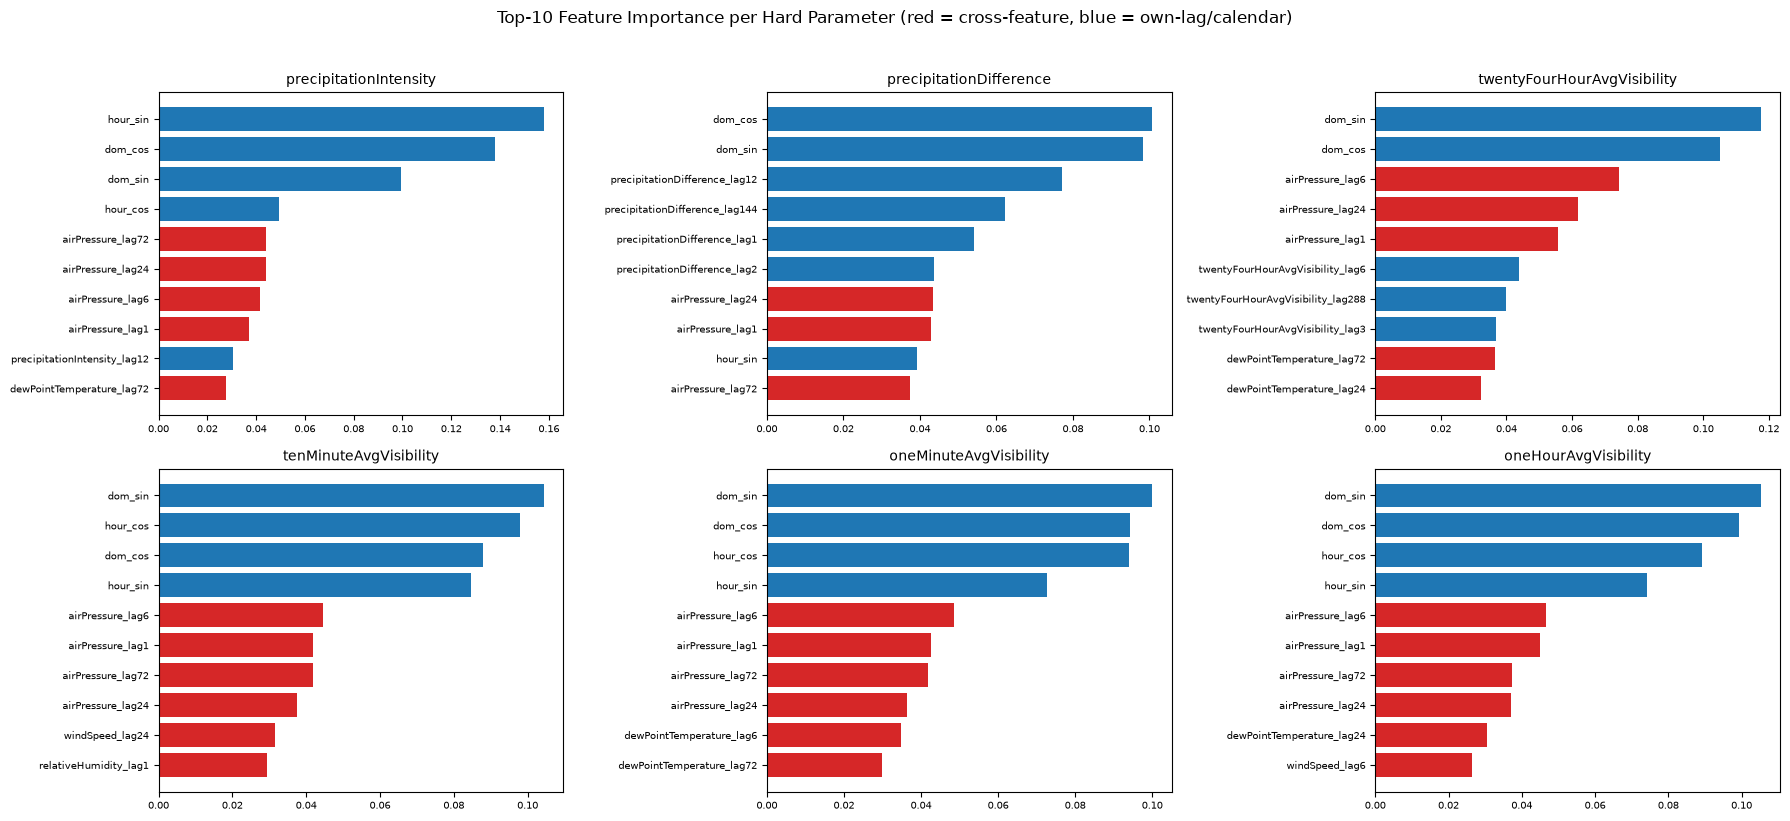

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, c in zip(axes.ravel(), HARD_PARAMS):
    importances = pd.Series(xgb_models[c].feature_importances_, index=xgb_feat_order[c])
    top10 = importances.sort_values(ascending=False).head(10)
    colors = ["#d62728" if any(cf in feat for cf in CROSS_FEATURES) else "#1f77b4" for feat in top10.index]
    ax.barh(top10.index[::-1], top10.values[::-1], color=colors[::-1])
    ax.set_title(c, fontsize=10)
    ax.tick_params(labelsize=7)
fig.suptitle("Top-10 Feature Importance per Hard Parameter (red = cross-feature, blue = own-lag/calendar)",
             fontsize=12, y=1.02)
fig.tight_layout()
fig.savefig("feature_importance_hybrid_v3.png", dpi=110, bbox_inches="tight")
plt.show()


## 9. Plot the hard 6, v3 vs actual

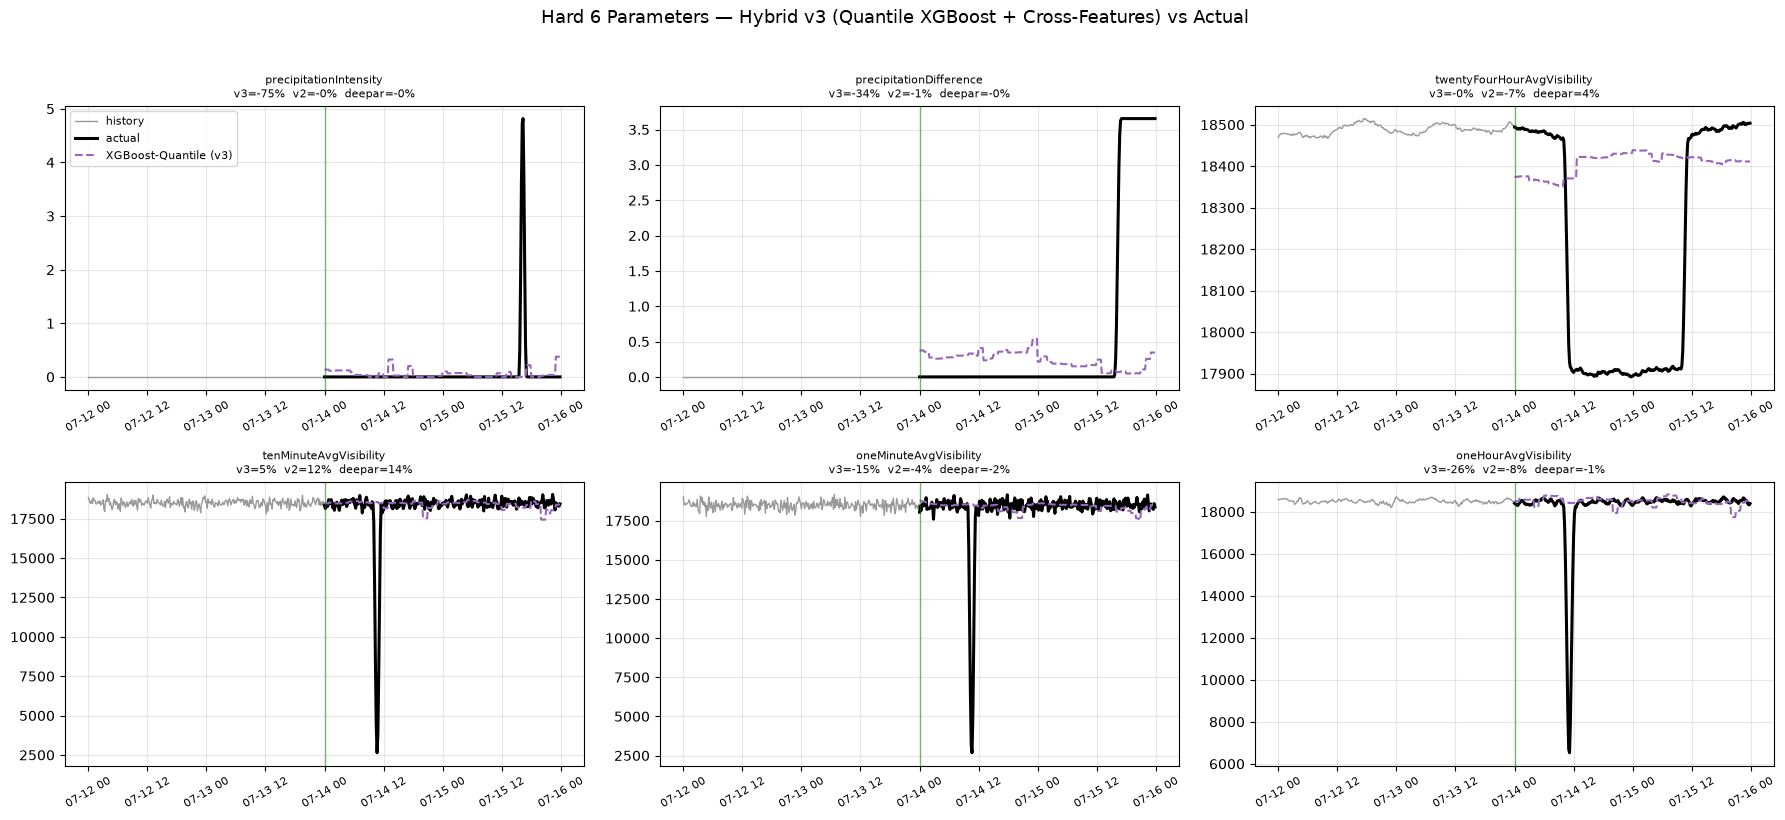

In [12]:
hist_tail = df_10min.iloc[-HORIZON - LOOKBACK:-HORIZON]
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, p in zip(axes.ravel(), HARD_PARAMS):
    ax.plot(hist_tail.index, hist_tail[p], color="0.6", lw=1, label="history")
    ax.plot(truth.index, truth[p], color="black", lw=2.2, label="actual")
    ax.plot(truth.index, hybrid_final[p], color="#9467bd", lw=1.5, ls="--", label="XGBoost-Quantile (v3)")
    ax.axvline(truth.index[0], color="green", lw=1, alpha=0.5)
    row = metrics_df[metrics_df["parameter"] == p].iloc[0]
    ax.set_title(f"{p}\nv3={row['hybrid_v3_skill_%']:.0f}%  v2={row['xgb_v2_skill_%']:.0f}%  "
                 f"deepar={row['deepar_hybrid_skill_%']:.0f}%", fontsize=8)
    ax.grid(alpha=0.3); ax.tick_params(axis="x", rotation=30, labelsize=8)
axes.ravel()[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Hard 6 Parameters — Hybrid v3 (Quantile XGBoost + Cross-Features) vs Actual", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig("forecast_plots_hybrid_v3.png", dpi=110, bbox_inches="tight")
plt.show()


## 10. Save outputs for the dashboard

In [13]:
fva = pd.DataFrame({"timestamp": truth.index})
for p in report_params:
    fva[f"{p}__actual"] = truth[p].values
    fva[f"{p}__hybrid_v3"] = hybrid_final[p].values
    fva[f"{p}__engine"] = ENGINE[p]
fva.to_csv("forecast_vs_actual_hybrid_v3.csv", index=False)

dup_fva = pd.DataFrame({"timestamp": test_df.index})
for keep, drop in DUPLICATES:
    dup_fva[f"{drop}__actual"] = df_10min[drop].iloc[-HORIZON:].values
    dup_fva[f"{drop}__reconstructed"] = dup_series[drop]
dup_fva.to_csv("duplicate_forecast_vs_actual_hybrid_v3.csv", index=False)

dup_recon_rows = []
for keep, drop in DUPLICATES:
    _, slope, intercept, r2 = recon_coef[drop]
    mae = mean_absolute_error(df_10min[drop].iloc[-HORIZON:].values, dup_series[drop])
    rmse = np.sqrt(mean_squared_error(df_10min[drop].iloc[-HORIZON:].values, dup_series[drop]))
    dup_recon_rows.append({"duplicate_parameter": drop, "reconstructed_from": keep,
                            "engine": ENGINE[keep], "slope": round(slope, 4),
                            "intercept": round(intercept, 4), "train_R2": round(r2, 5),
                            "held_out_MAE": round(mae, 4), "held_out_RMSE": round(rmse, 4)})
pd.DataFrame(dup_recon_rows).to_csv("duplicate_reconstruction_hybrid_v3.csv", index=False)

feat_imp_rows = []
for c in HARD_PARAMS:
    importances = pd.Series(xgb_models[c].feature_importances_, index=xgb_feat_order[c])
    for feat, imp in importances.sort_values(ascending=False).head(10).items():
        feat_imp_rows.append({"parameter": c, "feature": feat, "importance": round(float(imp), 4),
                               "is_cross_feature": any(cf in feat for cf in CROSS_FEATURES)})
pd.DataFrame(feat_imp_rows).to_csv("feature_importance_hybrid_v3.csv", index=False)

print("Saved: metrics_hybrid_v3.csv, forecast_vs_actual_hybrid_v3.csv, duplicate_reconstruction_hybrid_v3.csv,")
print("       duplicate_forecast_vs_actual_hybrid_v3.csv, feature_importance_hybrid_v3.csv, plot PNGs.")


Saved: metrics_hybrid_v3.csv, forecast_vs_actual_hybrid_v3.csv, duplicate_reconstruction_hybrid_v3.csv,
       duplicate_forecast_vs_actual_hybrid_v3.csv, feature_importance_hybrid_v3.csv, plot PNGs.


## 11. Conclusion

Section 7 is the actual verdict. If `hybrid_v3` beats both `xgb_v2` and `deepar_hybrid`
on most of the 6, that confirms the literature table's specific, concrete suggestions
(cross-features, MAE-targeted quantile loss, rare-event weighting) were the missing
piece — not a fancier architecture, but better-chosen inputs and a loss function that
matches the eval metric. Section 8's feature importance plot shows directly whether the
model actually learned to use the cross-features once they were available, which is
the most falsifiable check available here: if cross-features rank low in importance
even after being added, that's evidence these parameters are dominated by their own
short-term persistence/noise rather than synoptic meteorological coupling at this site
and horizon — a genuinely different (and equally valid) finding from "the model needed
better inputs."
